In [54]:
import numpy as np
print("Power flow project started")

Power flow project started


In [55]:
# line data
#(from bus, to bus, resistance, reactance)

lines = [
    (0, 1, 0.02, 0.06),
    (0, 2, 0.08, 0.24),
    (1, 2, 0.06, 0.18),
]
print(lines)

[(0, 1, 0.02, 0.06), (0, 2, 0.08, 0.24), (1, 2, 0.06, 0.18)]


In [56]:
# number of buses
n_buses = 3

#create empty 3x3 matrix
Ybus = np.zeros((n_buses, n_buses), dtype=complex)
print(Ybus)

[[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]]


In [57]:
for from_bus, to_bus, R, X in lines:
    Z = R + 1j * X
    Y = 1 / Z

    print("Impedance:", Z)
    print("Admittance:", Y)

Impedance: (0.02+0.06j)
Admittance: (5.000000000000001-15j)
Impedance: (0.08+0.24j)
Admittance: (1.2500000000000002-3.75j)
Impedance: (0.06+0.18j)
Admittance: (1.6666666666666667-5j)


In [58]:
# Fill the Y-bus matrix

for from_bus, to_bus, R, X in lines:
    Z = R + 1j * X
    Y = 1 / Z

    # Add admittance to diagonal positions
    Ybus[from_bus, from_bus] += Y
    Ybus[to_bus, to_bus] += Y

    # Subtract admittance from off-diagonal positions
    Ybus[from_bus, to_bus] -= Y
    Ybus[to_bus, from_bus] -= Y

print(Ybus)

[[ 6.25      -18.75j -5.        +15.j   -1.25       +3.75j]
 [-5.        +15.j    6.66666667-20.j   -1.66666667 +5.j  ]
 [-1.25       +3.75j -1.66666667 +5.j    2.91666667 -8.75j]]


In [59]:
# -------------------------
# BUS DATA
# -------------------------

# Bus 1 - Slack bus
V1 = 1.04
angle1 = 0.0

# Bus 2 - Generator (PV bus)
P2 = 0.50
V2 = 1.01

# Bus 3 - Load (PQ bus)
P3 = -0.60
Q3 = -0.25

print("Bus data defined")

Bus data defined


In [60]:
# -------------------------
# INITIAL VOLTAGE GUESS
# -------------------------

V_mag = np.array([
    1.04,   # Bus 1
    1.01,   # Bus 2
    1.00    # Bus 3 - initial guess
])

angles = np.array([
    0.0,    # Bus 1
    0.0,    # Bus 2 - initial guess
    0.0     # Bus 3 - initial guess
])

print("Voltage magnitudes:", V_mag)
print("Voltage angles:", angles)

Voltage magnitudes: [1.04 1.01 1.  ]
Voltage angles: [0. 0. 0.]


In [61]:
# Convert voltage magnitude and angle into complex voltage

V = V_mag * np.exp(1j * angles)

print("Complex bus voltages:")
print(V)

Complex bus voltages:
[1.04+0.j 1.01+0.j 1.  +0.j]


In [62]:
# Calculate current injected at each bus

I = Ybus @ V

print("Bus currents:")
print(I)

Bus currents:
[ 0.2       -0.6j -0.13333333+0.4j -0.06666667+0.2j]


In [63]:
# Calculate complex power at each bus

S = V * np.conj(I)

P_calc = S.real
Q_calc = S.imag

print("Calculated active power P:")
print(P_calc)

print("Calculated reactive power Q:")
print(Q_calc)

Calculated active power P:
[ 0.208      -0.13466667 -0.06666667]
Calculated reactive power Q:
[ 0.624 -0.404 -0.2  ]


In [64]:
# -------------------------
# POWER MISMATCH
# -------------------------

dP2 = P2 - P_calc[1]
dP3 = P3 - P_calc[2]
dQ3 = Q3 - Q_calc[2]

mismatch = np.array([
    dP2,
    dP3,
    dQ3
])

print("Power mismatch:")
print(mismatch)

Power mismatch:
[ 0.63466667 -0.53333333 -0.05      ]


In [65]:
tolerance = 1e-6

max_mismatch = np.max(np.abs(mismatch))

print("Maximum mismatch:", max_mismatch)

if max_mismatch < tolerance:
    print("Power flow has converged")
else:
    print("Not converged yet")

Maximum mismatch: 0.6346666666666668
Not converged yet


In [66]:
# -------------------------
# BUILD THE JACOBIAN MATRIX
# -------------------------

G = Ybus.real
B = Ybus.imag

J = np.zeros((3, 3))

# Bus indices
i2 = 1
i3 = 2

# ----- Row 1: derivatives of P2 -----

J[0, 0] = -Q_calc[i2] - B[i2, i2] * V_mag[i2]**2

theta23 = angles[i2] - angles[i3]

J[0, 1] = (
    V_mag[i2] * V_mag[i3] *
    (G[i2, i3] * np.sin(theta23)
     - B[i2, i3] * np.cos(theta23))
)

J[0, 2] = (
    V_mag[i2] *
    (G[i2, i3] * np.cos(theta23)
     + B[i2, i3] * np.sin(theta23))
)

# ----- Row 2: derivatives of P3 -----

theta32 = angles[i3] - angles[i2]

J[1, 0] = (
    V_mag[i3] * V_mag[i2] *
    (G[i3, i2] * np.sin(theta32)
     - B[i3, i2] * np.cos(theta32))
)

J[1, 1] = -Q_calc[i3] - B[i3, i3] * V_mag[i3]**2

J[1, 2] = (
    P_calc[i3] / V_mag[i3]
    + G[i3, i3] * V_mag[i3]
)

# ----- Row 3: derivatives of Q3 -----

J[2, 0] = (
    -V_mag[i3] * V_mag[i2] *
    (G[i3, i2] * np.cos(theta32)
     + B[i3, i2] * np.sin(theta32))
)

J[2, 1] = (
    P_calc[i3]
    - G[i3, i3] * V_mag[i3]**2
)

J[2, 2] = (
    Q_calc[i3] / V_mag[i3]
    - B[i3, i3] * V_mag[i3]
)

print("Jacobian matrix:")
print(J)

Jacobian matrix:
[[20.806      -5.05       -1.68333333]
 [-5.05        8.95        2.85      ]
 [ 1.68333333 -2.98333333  8.55      ]]


In [67]:
# Solve for the corrections

correction = np.linalg.solve(J, mismatch)

print("Corrections:")
print(correction)

Corrections:
[ 0.01848526 -0.04152507 -0.02397661]


In [68]:
# Update voltage angles

angles[1] += correction[0]
angles[2] += correction[1]

# Update Bus 3 voltage magnitude

V_mag[2] += correction[2]

print("Updated voltage magnitudes:")
print(V_mag)

print("Updated voltage angles in radians:")
print(angles)

print("Updated voltage angles in degrees:")
print(np.degrees(angles))

Updated voltage magnitudes:
[1.04       1.01       0.97602339]
Updated voltage angles in radians:
[ 0.          0.01848526 -0.04152507]
Updated voltage angles in degrees:
[ 0.          1.05912765 -2.37921149]


In [69]:
# -------------------------
# RECALCULATE POWER
# -------------------------

# Convert updated voltage values into complex form
V = V_mag * np.exp(1j * angles)

# Calculate current
I = Ybus @ V

# Calculate complex power
S = V * np.conj(I)

P_calc = S.real
Q_calc = S.imag

# New mismatches
dP2 = P2 - P_calc[1]
dP3 = P3 - P_calc[2]
dQ3 = Q3 - Q_calc[2]

mismatch = np.array([
    dP2,
    dP3,
    dQ3
])

print("Calculated P:", P_calc)
print("Calculated Q:", Q_calc)
print("New mismatch:", mismatch)
print("Maximum mismatch:", np.max(np.abs(mismatch)))

Calculated P: [ 0.10794283  0.49639452 -0.58289996]
Calculated Q: [ 0.76788795 -0.46696907 -0.2366067 ]
New mismatch: [ 0.00360548 -0.01710004 -0.0133933 ]
Maximum mismatch: 0.01710004005172716


In [70]:
# -------------------------
# NEWTON-RAPHSON POWER FLOW
# -------------------------

# Reset initial guesses
V_mag = np.array([1.04, 1.01, 1.00])
angles = np.array([0.0, 0.0, 0.0])

tolerance = 1e-6
max_iterations = 20

for iteration in range(max_iterations):

    # Calculate complex bus voltages
    V = V_mag * np.exp(1j * angles)

    # Calculate currents and powers
    I = Ybus @ V
    S = V * np.conj(I)

    P_calc = S.real
    Q_calc = S.imag

    # Calculate mismatch
    mismatch = np.array([
        P2 - P_calc[1],
        P3 - P_calc[2],
        Q3 - Q_calc[2]
    ])

    max_mismatch = np.max(np.abs(mismatch))

    print(
        "Iteration", iteration + 1,
        "- Maximum mismatch =", max_mismatch
    )

    # Check convergence
    if max_mismatch < tolerance:
        print("Power flow converged!")
        break

    # Separate Ybus into conductance and susceptance
    G = Ybus.real
    B = Ybus.imag

    # Create Jacobian
    J = np.zeros((3, 3))

    i2 = 1
    i3 = 2

    theta23 = angles[i2] - angles[i3]
    theta32 = angles[i3] - angles[i2]

    # Row 1 - P2
    J[0, 0] = -Q_calc[i2] - B[i2, i2] * V_mag[i2]**2

    J[0, 1] = (
        V_mag[i2] * V_mag[i3] *
        (G[i2, i3] * np.sin(theta23)
         - B[i2, i3] * np.cos(theta23))
    )

    J[0, 2] = (
        V_mag[i2] *
        (G[i2, i3] * np.cos(theta23)
         + B[i2, i3] * np.sin(theta23))
    )

    # Row 2 - P3
    J[1, 0] = (
        V_mag[i3] * V_mag[i2] *
        (G[i3, i2] * np.sin(theta32)
         - B[i3, i2] * np.cos(theta32))
    )

    J[1, 1] = (
        -Q_calc[i3]
        - B[i3, i3] * V_mag[i3]**2
    )

    J[1, 2] = (
        P_calc[i3] / V_mag[i3]
        + G[i3, i3] * V_mag[i3]
    )

    # Row 3 - Q3
    J[2, 0] = (
        -V_mag[i3] * V_mag[i2] *
        (G[i3, i2] * np.cos(theta32)
         + B[i3, i2] * np.sin(theta32))
    )

    J[2, 1] = (
        P_calc[i3]
        - G[i3, i3] * V_mag[i3]**2
    )

    J[2, 2] = (
        Q_calc[i3] / V_mag[i3]
        - B[i3, i3] * V_mag[i3]
    )

    # Solve for correction
    correction = np.linalg.solve(J, mismatch)

    # Update unknown variables
    angles[1] += correction[0]
    angles[2] += correction[1]
    V_mag[2] += correction[2]

Iteration 1 - Maximum mismatch = 0.6346666666666668
Iteration 2 - Maximum mismatch = 0.01710004005172716
Iteration 3 - Maximum mismatch = 4.467648806461e-05
Iteration 4 - Maximum mismatch = 3.3564584445144874e-10
Power flow converged!


In [71]:
print("\nFinal Results")

for i in range(3):
    print(
        f"Bus {i+1}: "
        f"Voltage = {V_mag[i]:.4f} pu, "
        f"Angle = {np.degrees(angles[i]):.4f} degrees"
    )


Final Results
Bus 1: Voltage = 1.0400 pu, Angle = 0.0000 degrees
Bus 2: Voltage = 1.0100 pu, Angle = 1.0383 degrees
Bus 3: Voltage = 0.9738 pu, Angle = -2.4725 degrees


In [72]:
# -------------------------
# LINE POWER FLOWS AND LOSSES
# -------------------------

total_real_loss = 0
total_reactive_loss = 0

for from_bus, to_bus, R, X in lines:

    Z = R + 1j * X
    Y = 1 / Z

    # Current flowing from one bus to the other
    I_from_to = (V[from_bus] - V[to_bus]) * Y
    I_to_from = (V[to_bus] - V[from_bus]) * Y

    # Complex power flow
    S_from_to = V[from_bus] * np.conj(I_from_to)
    S_to_from = V[to_bus] * np.conj(I_to_from)

    # Power loss in the line
    S_loss = S_from_to + S_to_from

    total_real_loss += S_loss.real
    total_reactive_loss += S_loss.imag

    print(
        f"Line {from_bus + 1}-{to_bus + 1}:"
    )

    print(
        f"  Power {from_bus + 1} -> {to_bus + 1}: "
        f"{S_from_to.real:.4f} + j{S_from_to.imag:.4f} pu"
    )

    print(
        f"  Power {to_bus + 1} -> {from_bus + 1}: "
        f"{S_to_from.real:.4f} + j{S_to_from.imag:.4f} pu"
    )

    print(
        f"  Real power loss: {S_loss.real:.4f} pu"
    )

    print()

print("Total real power loss:", total_real_loss, "pu")
print("Total reactive power loss:", total_reactive_loss, "pu")

print("Total real power loss:", total_real_loss * 100, "MW")
print("Total reactive power loss:", total_reactive_loss * 100, "MVAr")

Line 1-2:
  Power 1 -> 2: -0.1287 + j0.5658 pu
  Power 2 -> 1: 0.1349 + j-0.5471 pu
  Real power loss: 0.0062 pu

Line 1-3:
  Power 1 -> 3: 0.2510 + j0.2070 pu
  Power 3 -> 1: -0.2432 + j-0.1835 pu
  Real power loss: 0.0078 pu

Line 2-3:
  Power 2 -> 3: 0.3651 + j0.0915 pu
  Power 3 -> 2: -0.3568 + j-0.0665 pu
  Real power loss: 0.0083 pu

Total real power loss: 0.02238878920887219 pu
Total reactive power loss: 0.06716636762661655 pu
Total real power loss: 2.238878920887219 MW
Total reactive power loss: 6.716636762661656 MVAr


In [73]:
def run_power_flow(P3_value, Q3_value):

    # Initial guesses
    V_mag = np.array([1.04, 1.01, 1.00])
    angles = np.array([0.0, 0.0, 0.0])

    tolerance = 1e-6
    max_iterations = 20

    for iteration in range(max_iterations):

        V = V_mag * np.exp(1j * angles)

        I = Ybus @ V
        S = V * np.conj(I)

        P_calc = S.real
        Q_calc = S.imag

        mismatch = np.array([
            P2 - P_calc[1],
            P3_value - P_calc[2],
            Q3_value - Q_calc[2]
        ])

        if np.max(np.abs(mismatch)) < tolerance:
            break

        G = Ybus.real
        B = Ybus.imag

        J = np.zeros((3, 3))

        i2 = 1
        i3 = 2

        theta23 = angles[i2] - angles[i3]
        theta32 = angles[i3] - angles[i2]

        J[0, 0] = -Q_calc[i2] - B[i2, i2] * V_mag[i2]**2

        J[0, 1] = (
            V_mag[i2] * V_mag[i3] *
            (G[i2, i3] * np.sin(theta23)
             - B[i2, i3] * np.cos(theta23))
        )

        J[0, 2] = (
            V_mag[i2] *
            (G[i2, i3] * np.cos(theta23)
             + B[i2, i3] * np.sin(theta23))
        )

        J[1, 0] = (
            V_mag[i3] * V_mag[i2] *
            (G[i3, i2] * np.sin(theta32)
             - B[i3, i2] * np.cos(theta32))
        )

        J[1, 1] = (
            -Q_calc[i3]
            - B[i3, i3] * V_mag[i3]**2
        )

        J[1, 2] = (
            P_calc[i3] / V_mag[i3]
            + G[i3, i3] * V_mag[i3]
        )

        J[2, 0] = (
            -V_mag[i3] * V_mag[i2] *
            (G[i3, i2] * np.cos(theta32)
             + B[i3, i2] * np.sin(theta32))
        )

        J[2, 1] = (
            P_calc[i3]
            - G[i3, i3] * V_mag[i3]**2
        )

        J[2, 2] = (
            Q_calc[i3] / V_mag[i3]
            - B[i3, i3] * V_mag[i3]
        )

        correction = np.linalg.solve(J, mismatch)

        angles[1] += correction[0]
        angles[2] += correction[1]
        V_mag[2] += correction[2]

    # Recalculate final voltage
    V = V_mag * np.exp(1j * angles)

    # Calculate total real power loss
    total_real_loss = 0

    for from_bus, to_bus, R, X in lines:

        Z = R + 1j * X
        Y = 1 / Z

        I_from_to = (V[from_bus] - V[to_bus]) * Y
        I_to_from = (V[to_bus] - V[from_bus]) * Y

        S_from_to = V[from_bus] * np.conj(I_from_to)
        S_to_from = V[to_bus] * np.conj(I_to_from)

        total_real_loss += (S_from_to + S_to_from).real

    return V_mag[2], np.degrees(angles[2]), total_real_loss * 100



base = run_power_flow(-0.60, -0.25)
high_demand = run_power_flow(-0.75, -0.25)
solar = run_power_flow(-0.40, -0.25)

print("Base case:", base)
print("High demand:", high_demand)
print("20 MW solar:", solar)

Base case: (np.float64(0.9738294356573788), np.float64(-2.4725214068806514), np.float64(2.238878920887219))
High demand: (np.float64(0.9672027593736497), np.float64(-3.548087823944053), np.float64(2.909391296785444))
20 MW solar: (np.float64(0.9820958499555181), np.float64(-1.0631229713515187), np.float64(1.6682531071980948))


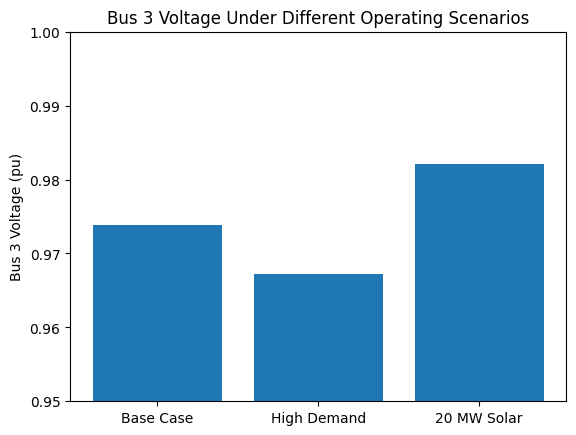

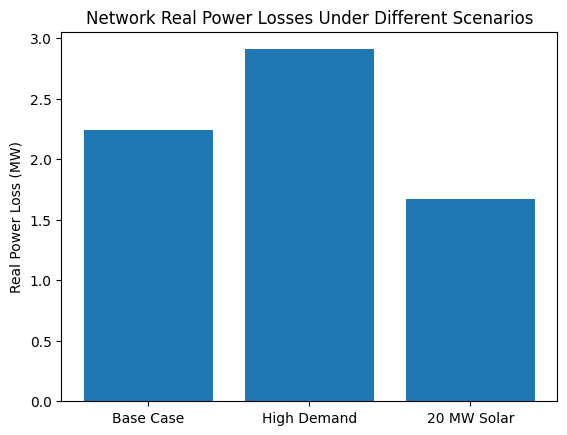

In [74]:
import matplotlib.pyplot as plt

scenarios = ["Base Case", "High Demand", "20 MW Solar"]

voltages = [
    base[0],
    high_demand[0],
    solar[0]
]

losses = [
    base[2],
    high_demand[2],
    solar[2]
]

plt.figure()

plt.bar(scenarios, voltages)

plt.ylabel("Bus 3 Voltage (pu)")
plt.title("Bus 3 Voltage Under Different Operating Scenarios")

plt.ylim(0.95, 1.00)

plt.show()

plt.figure()

plt.bar(scenarios, losses)

plt.ylabel("Real Power Loss (MW)")
plt.title("Network Real Power Losses Under Different Scenarios")

plt.show()